<a href="https://colab.research.google.com/github/Varsh555/ML2_lab/blob/main/Learning_First_order_rules.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install networkx matplotlib pandas seaborn -q

LEARN-ONE-RULE

Learned Rule:
Reads(x,y)  ->  Recommend(x,y)

Search History:
--------------------------------------------------------------------------------
Round 0: (most general)
    Positive covered : 7
    Negative covered : 3
    Quality          : 0.70
    Covered IDs      : ['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10']

Round 1: Reads(x,y)
    Positive covered : 4
    Negative covered : 0
    Quality          : 1.00
    Covered IDs      : ['E1', 'E4', 'E7', 'E9']



/tmp/ipykernel_1395/989858075.py:736: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


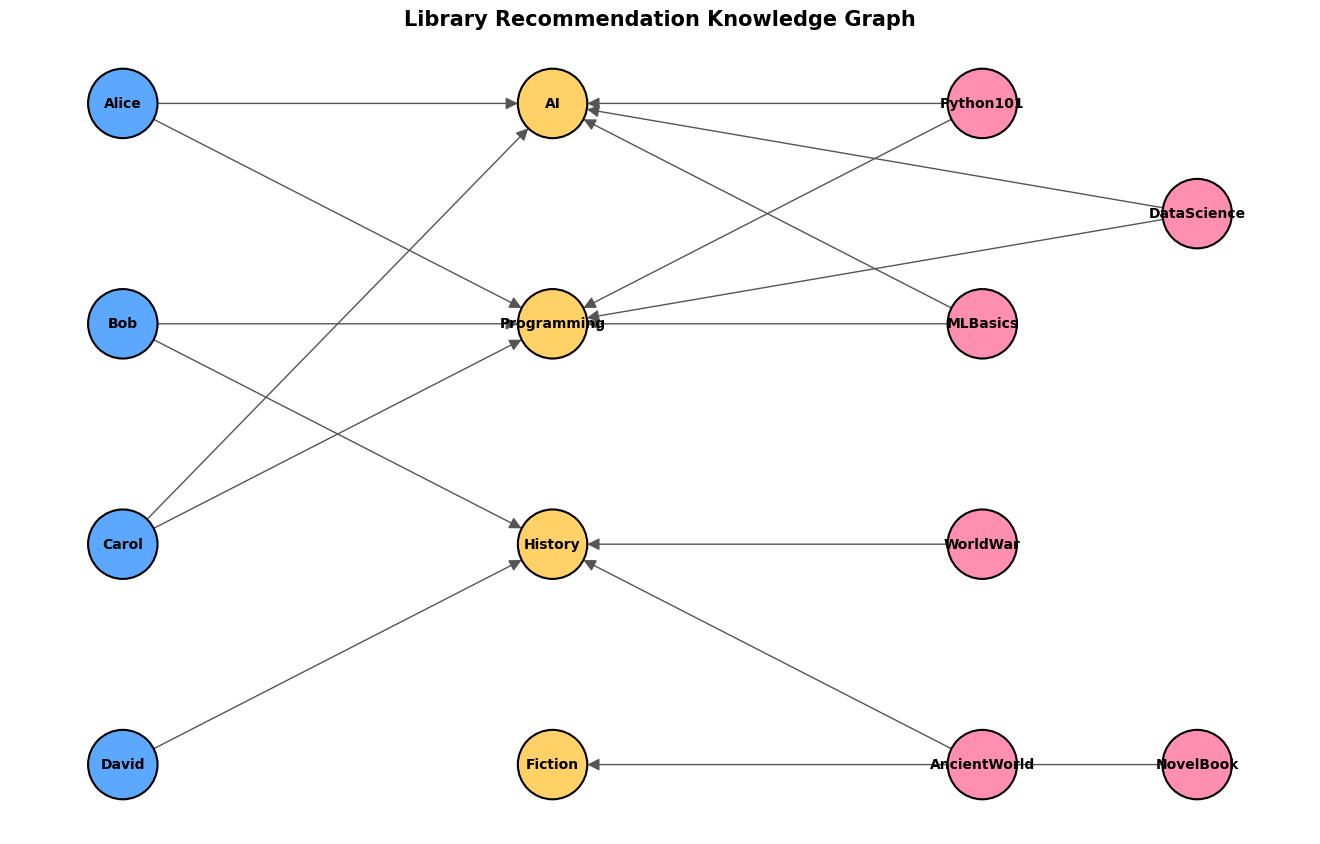

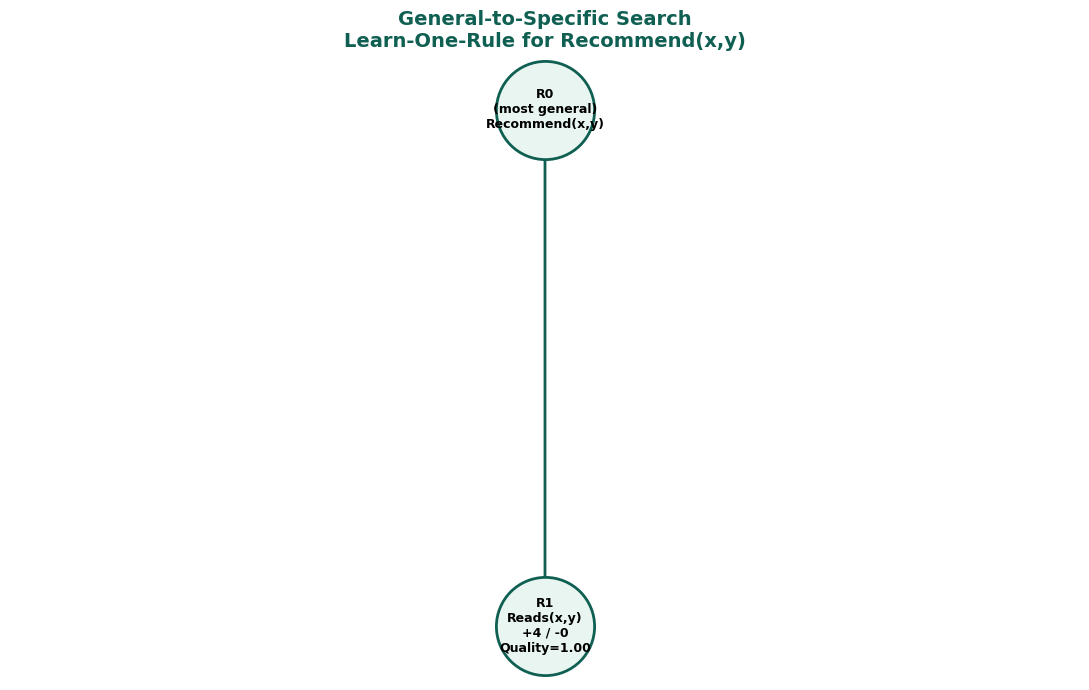

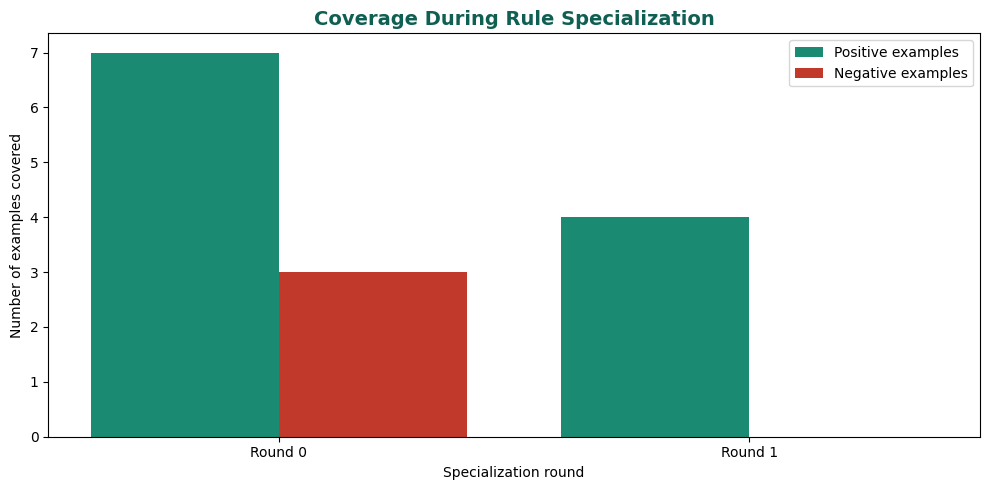

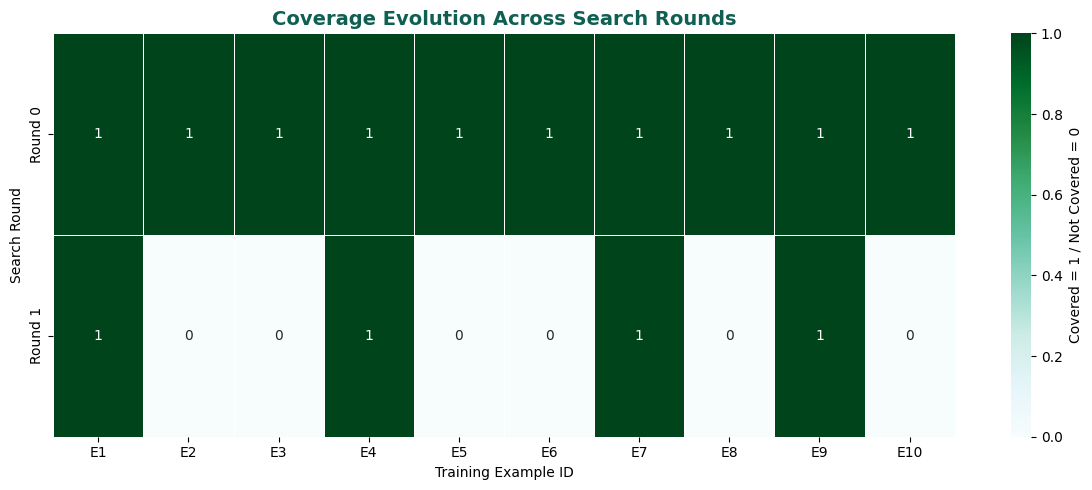


FINAL RULE VERIFICATION
Example Student         Book Actual Class Rule Result Reads(x,y)
     E1   Alice    Python101     Positive     Covered          T
     E2   Alice     MLBasics     Positive Not Covered          F
     E3   Alice     WorldWar     Negative Not Covered          F
     E4     Bob     WorldWar     Positive     Covered          T
     E5     Bob    Python101     Negative Not Covered          F
     E6     Bob AncientWorld     Positive Not Covered          F
     E7   Carol     MLBasics     Positive     Covered          T
     E8   Carol  DataScience     Positive Not Covered          F
     E9   David AncientWorld     Positive     Covered          T
    E10   David     MLBasics     Negative Not Covered          F

FINAL SUMMARY
Learned Rule:
Reads(x,y)  ->  Recommend(x,y)

Positive examples covered : 4
Negative examples covered : 0
Rule quality              : 1.00

Covered example IDs:
['E1', 'E4', 'E7', 'E9']


In [2]:
# ============================================================
# FIRST-ORDER RULE LEARNING
# LEARN-ONE-RULE ALGORITHM
# Dataset: Library Book Recommendation
# ============================================================

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# ============================================================
# 1. BACKGROUND KNOWLEDGE
# ============================================================
#
# Goal:
#
#     Recommend(Student, Book)
#
# We want to learn a rule that explains which books
# should be recommended to students.
#
# Background predicates:
#
#     Likes(Student, Genre)
#     Genre(Book, Genre)
#     Reads(Student, Book)
#     Student(Student)
#     Popular(Book)
#
# ============================================================

facts = {

    # --------------------------------------------------------
    # Student likes
    # --------------------------------------------------------

    "Likes": {
        ("Alice", "AI"),
        ("Alice", "Programming"),

        ("Bob", "History"),
        ("Bob", "Programming"),

        ("Carol", "AI"),
        ("Carol", "Programming"),

        ("David", "History"),
    },


    # --------------------------------------------------------
    # Book genres
    # --------------------------------------------------------

    "Genre": {
        ("Python101", "Programming"),
        ("Python101", "AI"),

        ("MLBasics", "AI"),
        ("MLBasics", "Programming"),

        ("WorldWar", "History"),

        ("AncientWorld", "History"),

        ("DataScience", "AI"),
        ("DataScience", "Programming"),

        ("NovelBook", "Fiction"),
    },


    # --------------------------------------------------------
    # Books already read
    # --------------------------------------------------------

    "Reads": {
        ("Alice", "Python101"),
        ("Bob", "WorldWar"),
        ("Carol", "MLBasics"),
        ("David", "AncientWorld"),
    },


    # --------------------------------------------------------
    # Student predicate
    # --------------------------------------------------------

    "Student": {
        ("Alice",),
        ("Bob",),
        ("Carol",),
        ("David",),
    },


    # --------------------------------------------------------
    # Popular books
    # --------------------------------------------------------

    "Popular": {
        ("Python101",),
        ("MLBasics",),
        ("DataScience",),
    }
}


# ============================================================
# 2. TRAINING EXAMPLES
# ============================================================
#
# Format:
#
#     (Example_ID, Student, Book, Class)
#
# True  = positive example
# False = negative example
#
# ============================================================

examples = [

    ("E1", "Alice", "Python101", True),
    ("E2", "Alice", "MLBasics", True),
    ("E3", "Alice", "WorldWar", False),
    ("E4", "Bob", "WorldWar", True),
    ("E5", "Bob", "Python101", False),
    ("E6", "Bob", "AncientWorld", True),
    ("E7", "Carol", "MLBasics", True),
    ("E8", "Carol", "DataScience", True),
    ("E9", "David", "AncientWorld", True),
    ("E10", "David", "MLBasics", False),
]


# ============================================================
# 3. CANDIDATE LITERALS
# ============================================================
#
# Every literal is a possible condition that can be added
# to the rule.
#
# x = Student
# y = Book
#
# ============================================================

candidate_literals = {

    "Likes(x,AI)": lambda x, y:
        (x, "AI") in facts["Likes"],

    "Likes(x,Programming)": lambda x, y:
        (x, "Programming") in facts["Likes"],

    "Likes(x,History)": lambda x, y:
        (x, "History") in facts["Likes"],

    "Genre(y,AI)": lambda x, y:
        (y, "AI") in facts["Genre"],

    "Genre(y,Programming)": lambda x, y:
        (y, "Programming") in facts["Genre"],

    "Genre(y,History)": lambda x, y:
        (y, "History") in facts["Genre"],

    "Genre(y,Fiction)": lambda x, y:
        (y, "Fiction") in facts["Genre"],

    "Reads(x,y)": lambda x, y:
        (x, y) in facts["Reads"],

    "Student(x)": lambda x, y:
        (x,) in facts["Student"],

    "Popular(y)": lambda x, y:
        (y,) in facts["Popular"],
}


# ============================================================
# 4. RULE STRING FUNCTION
# ============================================================

def rule_to_string(rule_body):

    if not rule_body:
        return "(most general)"

    return " AND ".join(rule_body)


# ============================================================
# 5. EVALUATE RULE
# ============================================================

def evaluate_rule(
    rule_body,
    examples
):

    positive_count = 0
    negative_count = 0

    covered_examples = []


    # --------------------------------------------------------
    # Check every training example
    # --------------------------------------------------------

    for (
        example_id,
        student,
        book,
        label
    ) in examples:

        # Every literal in the rule must be true
        satisfied = all(
            candidate_literals[literal](
                student,
                book
            )
            for literal in rule_body
        )


        # ----------------------------------------------------
        # If the rule covers the example
        # ----------------------------------------------------

        if satisfied:

            covered_examples.append(
                (
                    example_id,
                    student,
                    book,
                    label
                )
            )


            if label:

                positive_count += 1

            else:

                negative_count += 1


    return (
        positive_count,
        negative_count,
        covered_examples
    )


# ============================================================
# 6. CALCULATE RULE QUALITY
# ============================================================

def rule_quality(
    positive_count,
    negative_count
):

    total = (
        positive_count
        + negative_count
    )


    if total == 0:

        return 0.0


    return (
        positive_count / total
    )


# ============================================================
# 7. LEARN-ONE-RULE
#    GENERAL → SPECIFIC SEARCH
# ============================================================

def learn_one_rule(
    examples,
    candidate_literals
):

    rule_body = []

    history = []

    used_literals = set()

    round_number = 0


    # --------------------------------------------------------
    # Initial most-general rule
    # --------------------------------------------------------

    pos, neg, covered = evaluate_rule(
        rule_body,
        examples
    )


    history.append({

        "round": round_number,

        "rule": rule_to_string(
            rule_body
        ),

        "pos_covered": pos,

        "neg_covered": neg,

        "quality": rule_quality(
            pos,
            neg
        ),

        "covered_ids": [
            item[0]
            for item in covered
        ]

    })


    # ========================================================
    # SPECIALIZATION LOOP
    # ========================================================

    while True:

        # ----------------------------------------------------
        # Check whether current rule is pure
        # ----------------------------------------------------

        pos, neg, covered = evaluate_rule(
            rule_body,
            examples
        )


        if neg == 0:

            break


        # ----------------------------------------------------
        # Generate possible specializations
        # ----------------------------------------------------

        candidates = []


        for literal in candidate_literals:

            if literal in used_literals:

                continue


            trial_rule = (
                rule_body
                + [literal]
            )


            p, n, covered_trial = (
                evaluate_rule(
                    trial_rule,
                    examples
                )
            )


            quality = rule_quality(
                p,
                n
            )


            candidates.append({

                "literal": literal,

                "rule": trial_rule,

                "positive": p,

                "negative": n,

                "quality": quality,

                "covered_ids": [
                    item[0]
                    for item in covered_trial
                ]

            })


        # ----------------------------------------------------
        # Stop if no candidate exists
        # ----------------------------------------------------

        if not candidates:

            break


        # ----------------------------------------------------
        # Rank candidates
        #
        # 1. Purity / quality
        # 2. Positive coverage
        # 3. Fewer negatives
        # ----------------------------------------------------

        candidates.sort(

            key=lambda c: (
                c["quality"],
                c["positive"],
                -c["negative"]
            ),

            reverse=True
        )


        best_candidate = candidates[0]


        # ----------------------------------------------------
        # Add best literal to rule
        # ----------------------------------------------------

        best_literal = (
            best_candidate["literal"]
        )


        rule_body.append(
            best_literal
        )


        used_literals.add(
            best_literal
        )


        round_number += 1


        # ----------------------------------------------------
        # Save search history
        # ----------------------------------------------------

        history.append({

            "round": round_number,

            "rule": rule_to_string(
                rule_body
            ),

            "pos_covered":
                best_candidate["positive"],

            "neg_covered":
                best_candidate["negative"],

            "quality":
                best_candidate["quality"],

            "covered_ids":
                best_candidate["covered_ids"]

        })


    # ========================================================
    # FINAL RESULT
    # ========================================================

    final_pos, final_neg, final_covered = (
        evaluate_rule(
            rule_body,
            examples
        )
    )


    return (
        rule_body,
        history,
        final_covered
    )


# ============================================================
# 8. RUN LEARN-ONE-RULE
# ============================================================

rule_body, history, final_covered = (
    learn_one_rule(
        examples,
        candidate_literals
    )
)


rule_string = (
    rule_to_string(rule_body)
    + "  ->  Recommend(x,y)"
)


print("=" * 80)
print("LEARN-ONE-RULE")
print("=" * 80)

print(
    "\nLearned Rule:"
)

print(
    rule_string
)


print(
    "\nSearch History:"
)

print("-" * 80)


for h in history:

    print(
        f"Round {h['round']}: "
        f"{h['rule']}"
    )

    print(
        f"    Positive covered : "
        f"{h['pos_covered']}"
    )

    print(
        f"    Negative covered : "
        f"{h['neg_covered']}"
    )

    print(
        f"    Quality          : "
        f"{h['quality']:.2f}"
    )

    print(
        f"    Covered IDs      : "
        f"{h['covered_ids']}"
    )

    print()


# ============================================================
# 9. VISUALIZATION 1
#    KNOWLEDGE GRAPH
# ============================================================

KG = nx.DiGraph()


# ------------------------------------------------------------
# Student → Genre relationships
# ------------------------------------------------------------

KG.add_edges_from([

    ("Alice", "AI"),
    ("Alice", "Programming"),

    ("Bob", "History"),
    ("Bob", "Programming"),

    ("Carol", "AI"),
    ("Carol", "Programming"),

    ("David", "History"),

])


# ------------------------------------------------------------
# Book → Genre relationships
# ------------------------------------------------------------

KG.add_edges_from([

    ("Python101", "Programming"),
    ("Python101", "AI"),

    ("MLBasics", "AI"),
    ("MLBasics", "Programming"),

    ("WorldWar", "History"),

    ("AncientWorld", "History"),

    ("DataScience", "AI"),
    ("DataScience", "Programming"),

    ("NovelBook", "Fiction"),

])


# ------------------------------------------------------------
# Node positions
# ------------------------------------------------------------

kg_position = {

    # Students
    "Alice": (-4, 3),
    "Bob": (-4, 1),
    "Carol": (-4, -1),
    "David": (-4, -3),

    # Genres
    "AI": (0, 3),
    "Programming": (0, 1),
    "History": (0, -1),
    "Fiction": (0, -3),

    # Books
    "Python101": (4, 3),
    "MLBasics": (4, 1),
    "WorldWar": (4, -1),
    "AncientWorld": (4, -3),
    "DataScience": (6, 2),
    "NovelBook": (6, -3),
}


# ------------------------------------------------------------
# Node colors
# ------------------------------------------------------------

kg_colors = []


for node in KG.nodes():

    if node in [
        "Alice",
        "Bob",
        "Carol",
        "David"
    ]:

        kg_colors.append(
            "#5DA8FF"
        )

    elif node in [
        "AI",
        "Programming",
        "History",
        "Fiction"
    ]:

        kg_colors.append(
            "#FFD166"
        )

    else:

        kg_colors.append(
            "#FF8FB0"
        )


plt.figure(
    figsize=(13, 8)
)


nx.draw(
    KG,
    kg_position,
    with_labels=True,
    node_size=2500,
    node_color=kg_colors,
    edgecolors="black",
    linewidths=1.5,
    font_size=10,
    font_weight="bold",
    arrows=True,
    arrowsize=18,
    edge_color="#555555"
)


plt.title(
    "Library Recommendation Knowledge Graph",
    fontsize=15,
    fontweight="bold"
)


plt.axis("off")

plt.tight_layout()

plt.show()


# ============================================================
# 10. VISUALIZATION 2
#     GENERAL → SPECIFIC SEARCH LATTICE
# ============================================================

SearchGraph = nx.DiGraph()

search_labels = {}


# ------------------------------------------------------------
# Root node
# ------------------------------------------------------------

previous_node = "R0"

SearchGraph.add_node(
    previous_node
)


search_labels[
    previous_node
] = (
    "R0\n"
    "(most general)\n"
    "Recommend(x,y)"
)


# ------------------------------------------------------------
# Add specialization nodes
# ------------------------------------------------------------

for h in history[1:]:

    round_no = h["round"]

    node = f"R{round_no}"


    SearchGraph.add_node(
        node
    )


    SearchGraph.add_edge(
        previous_node,
        node
    )


    search_labels[node] = (

        f"R{round_no}\n"

        f"{h['rule']}\n"

        f"+{h['pos_covered']} / "
        f"-{h['neg_covered']}\n"

        f"Quality={h['quality']:.2f}"

    )


    previous_node = node


# ------------------------------------------------------------
# Position
# ------------------------------------------------------------

search_position = {

    node:
    (0, -i)

    for i, node
    in enumerate(
        SearchGraph.nodes()
    )

}


plt.figure(
    figsize=(11, 7)
)


nx.draw_networkx_edges(
    SearchGraph,
    search_position,
    arrows=True,
    arrowsize=20,
    edge_color="#0F5F52",
    width=2
)


nx.draw_networkx_nodes(
    SearchGraph,
    search_position,
    node_size=5000,
    node_color="#E8F5F0",
    edgecolors="#0F5F52",
    linewidths=2
)


nx.draw_networkx_labels(
    SearchGraph,
    search_position,
    search_labels,
    font_size=9,
    font_weight="bold"
)


plt.title(
    "General-to-Specific Search\n"
    "Learn-One-Rule for Recommend(x,y)",
    fontsize=14,
    fontweight="bold",
    color="#0F5F52"
)


plt.axis("off")

plt.tight_layout()

plt.show()


# ============================================================
# 11. VISUALIZATION 3
#     COVERAGE PER ROUND
# ============================================================

round_numbers = [
    h["round"]
    for h in history
]

positive_values = [
    h["pos_covered"]
    for h in history
]

negative_values = [
    h["neg_covered"]
    for h in history
]


x = list(
    range(
        len(round_numbers)
    )
)


plt.figure(
    figsize=(10, 5)
)


plt.bar(
    [
        i - 0.2
        for i in x
    ],

    positive_values,

    width=0.4,

    color="#1A8A72",

    label="Positive examples"
)


plt.bar(
    [
        i + 0.2
        for i in x
    ],

    negative_values,

    width=0.4,

    color="#C0392B",

    label="Negative examples"
)


plt.xticks(
    x,

    [
        f"Round {r}"
        for r in round_numbers
    ]
)


plt.ylabel(
    "Number of examples covered"
)


plt.xlabel(
    "Specialization round"
)


plt.title(
    "Coverage During Rule Specialization",
    fontsize=14,
    fontweight="bold",
    color="#0F5F52"
)


plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 12. VISUALIZATION 4
#     COVERAGE EVOLUTION HEATMAP
# ============================================================

example_ids = [
    item[0]
    for item in examples
]


heatmap_data = []


for h in history:

    covered_ids = set(
        h["covered_ids"]
    )


    row = [

        1
        if example_id in covered_ids
        else 0

        for example_id
        in example_ids

    ]


    heatmap_data.append(
        row
    )


heatmap_df = pd.DataFrame(

    heatmap_data,

    index=[
        f"Round {h['round']}"
        for h in history
    ],

    columns=example_ids
)


plt.figure(
    figsize=(12, 5)
)


sns.heatmap(

    heatmap_df,

    annot=True,

    fmt="d",

    cmap="BuGn",

    vmin=0,

    vmax=1,

    linewidths=0.5,

    linecolor="white",

    cbar_kws={
        "label":
        "Covered = 1 / Not Covered = 0"
    }

)


plt.title(
    "Coverage Evolution Across Search Rounds",
    fontsize=14,
    fontweight="bold",
    color="#0F5F52"
)


plt.xlabel(
    "Training Example ID"
)

plt.ylabel(
    "Search Round"
)


plt.tight_layout()

plt.show()


# ============================================================
# 13. FINAL VERIFICATION TABLE
# ============================================================

print()
print("=" * 80)
print("FINAL RULE VERIFICATION")
print("=" * 80)


verification_rows = []


for (
    example_id,
    student,
    book,
    label
) in examples:


    # --------------------------------------------------------
    # Evaluate every literal in final rule
    # --------------------------------------------------------

    literal_results = {

        literal:
        candidate_literals[literal](
            student,
            book
        )

        for literal in rule_body

    }


    rule_satisfied = all(
        literal_results.values()
    )


    # --------------------------------------------------------
    # Create row
    # --------------------------------------------------------

    row = {

        "Example":
            example_id,

        "Student":
            student,

        "Book":
            book,

        "Actual Class":
            "Positive"
            if label
            else "Negative",

        "Rule Result":
            "Covered"
            if rule_satisfied
            else "Not Covered"

    }


    # Add literal results
    for literal, value in (
        literal_results.items()
    ):

        row[literal] = (
            "T"
            if value
            else "F"
        )


    verification_rows.append(
        row
    )


verification_df = pd.DataFrame(
    verification_rows
)


print(
    verification_df.to_string(
        index=False
    )
)


# ============================================================
# 14. FINAL SUMMARY
# ============================================================

final_pos, final_neg, final_covered = (
    evaluate_rule(
        rule_body,
        examples
    )
)


print()
print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)


print(
    f"Learned Rule:"
)

print(
    f"{rule_string}"
)


print(
    f"\nPositive examples covered : "
    f"{final_pos}"
)


print(
    f"Negative examples covered : "
    f"{final_neg}"
)


print(
    f"Rule quality              : "
    f"{rule_quality(final_pos, final_neg):.2f}"
)


print(
    "\nCovered example IDs:"
)


print(
    [
        item[0]
        for item in final_covered
    ]
)
